#**ESAA_YB_3조_미니프로젝트**

팀원: 강수민, 김경민, 김나린, 김미소

## 1. 라이브러리 및 데이터

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

In [2]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 드라이브에서 movies_train 데이터 가져오기
train = pd.read_csv('/content/drive/MyDrive/data/movies_train.csv')
train.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


title : 영화의 제목  
distributor : 배급사  
genre : 장르  
release_time : 개봉일  
time : 상영시간(분)  
screening_rat : 상영등급  
director : 감독이름  
dir_prev_bfnum : 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화에서의 평균 관객수(단 관객수가 알려지지 않은 영화 제외)  
dir_prev_num : 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화의 개수(단 관객수가 알려지지 않은 영화 제외)  
num_staff : 스텝수  
num_actor : 주연배우수  
box_off_num : 관객수

## 2. 탐색적 자료 분석 (EDA)

### 2-1. 데이터 요약

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB


In [6]:
pd.options.display.float_format = '{:.1f}'.format

In [7]:
train.describe()

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.0,270.0,600.0,600.0,600.0,600.0
mean,100.9,1050442.9,0.9,151.1,3.7,708181.8
std,18.1,1791408.3,1.2,165.7,2.4,1828005.9
min,45.0,1.0,0.0,0.0,0.0,1.0
25%,89.0,20380.0,0.0,17.0,2.0,1297.2
50%,100.0,478423.6,0.0,82.5,3.0,12591.0
75%,114.0,1286568.6,2.0,264.0,4.0,479886.8
max,180.0,17615314.0,5.0,869.0,25.0,14262766.0


## 3. 분석 <br>
#**영화 장르와 관객 수 분석을 통한 대중적 장르 파악**

- 가설 : 액션, 드라마 장르가 인기가 많을 것이다.

장르와 관객 수 간의 분석에서는 따로 전처리를 진행하지 않았다.

<시각화>

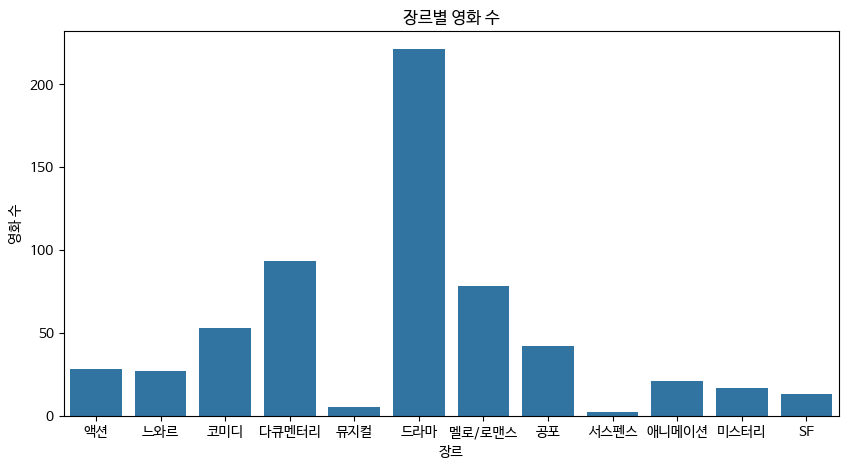

In [8]:
# 장르별 영화 수
plt.figure(figsize=(10, 5))
sns.countplot(x='genre', data=train)
plt.xlabel("장르")
plt.ylabel("영화 수")
plt.title("장르별 영화 수")
plt.show()

장르별 영화 수는 드라마가 압도적으로 많았고, 그 다음으로는 다큐멘터리, 멜로/로맨스 순으로 많았다.

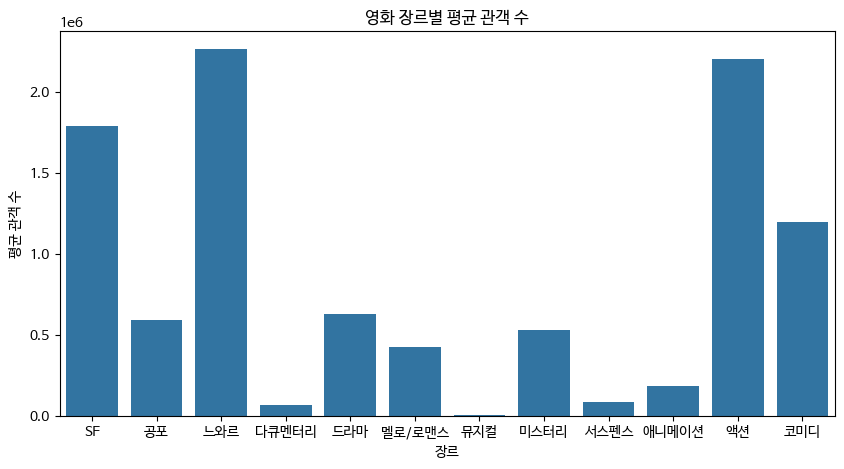

In [9]:
# 장르별 영화 관객수 평균
movie_genre_mean = train.groupby('genre')['box_off_num'].mean()
plt.figure(figsize=(10, 5))
sns.barplot(x = movie_genre_mean.index, y = movie_genre_mean.values)
plt.xlabel("장르")
plt.ylabel("평균 관객 수")
plt.title("영화 장르별 평균 관객 수")
plt.show()

느와르, 액션, SF 순으로 평균 관객 수가 많았다. 드라마 장르는 영화 수가 가장 많은 것에 비해서는 평균 관객 수가 그다지 많지 않았다.

In [10]:
# 인기 영화 기준 선정
train['box_off_num'].describe()

,box_off_num
count,600.0
mean,708181.8
std,1828005.9
min,1.0
25%,1297.2
50%,12591.0
75%,479886.8
max,14262766.0


관객수의 Q3이 479886명이므로, 반올림하여 관객수가 4800000명인 영화를 인기영화의 기준으로 했다.

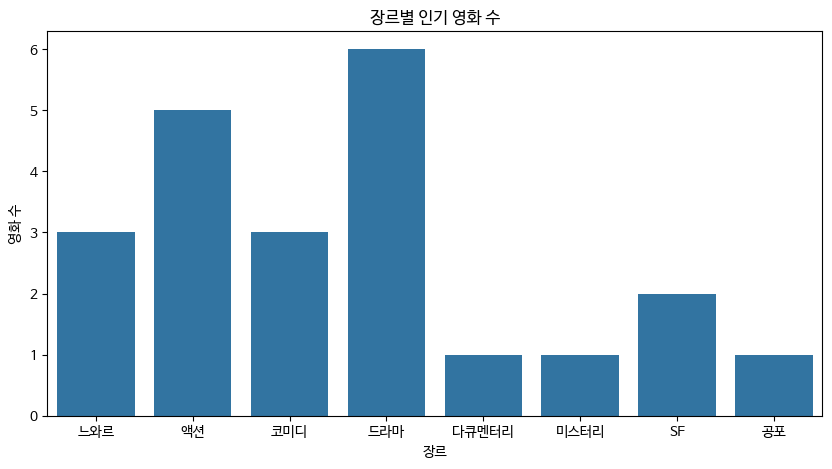

In [11]:
# 장르 별 인기 영화 수
movie_famous = train[train['box_off_num'] > 4800000][['genre', 'box_off_num']]
plt.figure(figsize=(10, 5))
sns.countplot(x='genre', data=movie_famous)
plt.xlabel("장르")
plt.ylabel("영화 수")
plt.title("장르별 인기 영화 수")
plt.show()

인기 영화만 추려 그래프를 그려본 결과 드라마 장르에서 6개로 가장 많았고, 그 다음으로는 액션 장르가 5개로 많았다. 느와르, 코미디 장르도 3개씩으로 꽤 있었다. 드라마 장르는 인기 영화가 많이 나오긴 했지만 영화 수 자체가 많아서 평균적으로는 관객 수가 적었다. 액션, 느와르 장르가 평균 관객 수도 많고 인기 영화도 많이 배출해 대중적인 장르라고 볼 수 있다.



# **배급사와 스텝수의 관계 및 그에 따른 흥행 척도**

- 가설 : 대형 자본을 가진 배급사가 제작하는 영화일수록 더 많은 스텝을 투입할 것이며, 이는 높은 관객 수로 이어질 것이다.

<데이터 전처리>
- 결측치 처리 : num_staff 컬럼의 결측치를 0으로 처리하여 분석의 연속성을 확보함
- 데이터 재그룹화 : 160여개의 배급사를 전부 비교하는 것은 무의미하다고 판단하여 영화를 가장 많이 낸 상위 10개 배급사를 'train_top10'으로 추출

In [12]:
# 1. 스텝수 결측치는 0으로 채우기
train['num_staff'] = train['num_staff'].fillna(0)

# 2. 배급사가 너무 많으니 영화를 가장 많이 낸 상위 10개 배급사만 추출
top_distributors = train['distributor'].value_counts().head(10).index
train_top10 = train[train['distributor'].isin(top_distributors)]

print("상위 10개 배급사 리스트:", list(top_distributors))

상위 10개 배급사 리스트: ['CJ 엔터테인먼트', '롯데엔터테인먼트', '(주)NEW', '(주)마운틴픽쳐스', '(주)쇼박스', '인디스토리', '골든타이드픽처스', '(주) 케이알씨지', '시너지', '(주)키노아이']


<시각화>

(1) 주요 배급사별 평균 스텝수

"어떤 배급사가 영화 한 편에 스텝을 가장 많이 쓸까?"

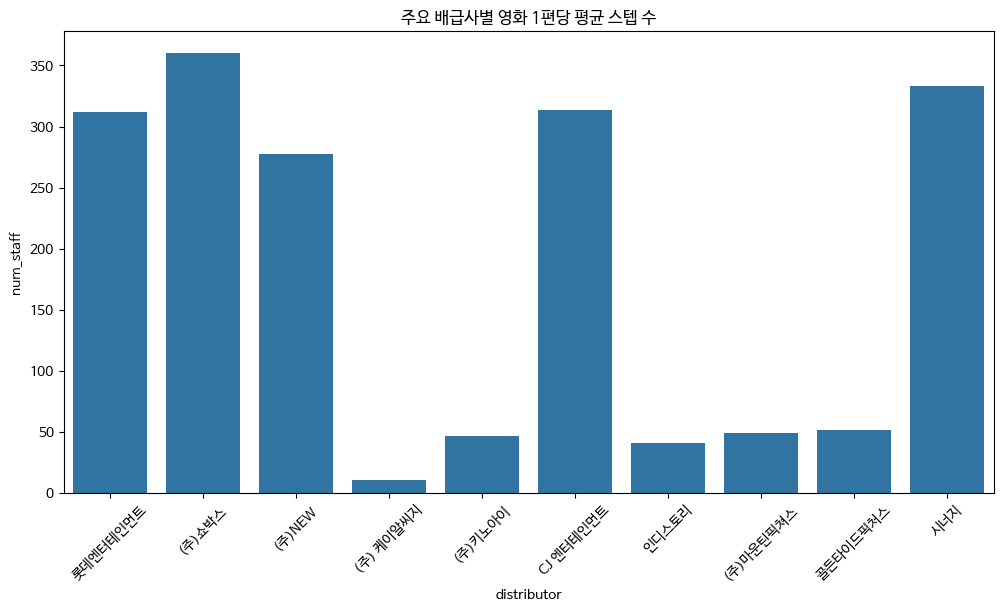

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(data=train_top10, x='distributor', y='num_staff', errorbar=None)
plt.title('주요 배급사별 영화 1편당 평균 스텝 수')
plt.xticks(rotation=45)
plt.show()

- 분석 결과 : CJ, 롯데, NEW, 쇼박스 같은 대형 배급사들이 영화 한 편에 투입하는 평균 스텝 수가 중소 배급사에 비해 압도적으로 많다.
- 배급사들의 제작 규모를 확인해 본 결과, 대형 배급사일수록 인적 자본을 많이 투입한다는 것을 알 수 있고 배급사의 자본이 스텝수로 이어진다는 사실까지 확인할 수 있다.



(2) 스텝 수 구간별 평균 관객수

"스텝이 많을 수록 관객수가 많을까?"

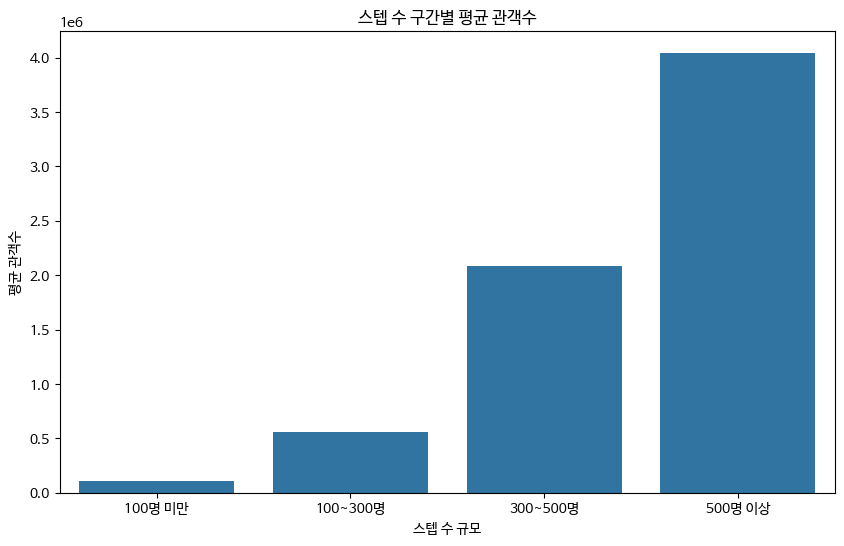

In [14]:
def staff_band(staff):
    if staff < 100: return '100명 미만'
    elif staff < 300: return '100~300명'
    elif staff < 500: return '300~500명'
    else: return '500명 이상'

train['스텝수_구간'] = train['num_staff'].apply(staff_band)

order = ['100명 미만', '100~300명', '300~500명', '500명 이상']

plt.figure(figsize=(10, 6))
sns.barplot(data=train, x='스텝수_구간', y='box_off_num', order=order, errorbar=None)

plt.title('스텝 수 구간별 평균 관객수')
plt.xlabel('스텝 수 규모')
plt.ylabel('평균 관객수')
plt.show()

스텝 수를 구간 별로 나누어 평균 관객 수를 확인했을 때, 스텝 수가 많아질수록 관객 수도 계단식으로 상승하는 '우상향' 모습이 나타난다.<br>결론적으로 개별 영화마다 차이는 있겠지만 전체적인 흐름을 보면 스텝 수가 평균 관객수에 정비례함을 알 수 있다. 이는 많은 인력이 투입될수록 영화의 완성도가 높아지거나 거대한 자본이 들어간 만큼 더 적극적인 마케팅이 이루어져 흥행 확률을 높인다는 것을 의미한다.

(3) 배급사 수준별 관객수 분포

"대형 배급사 (상위 4개)와 기타 배급사의 흥행 규모에는 차이가 있을까?"

- 이상치 발견 및 제거 : 초기 분석 시 개봉 영화 수 기준 상위권에 있던 '마운틴픽쳐스'를 발견 -> 해당 배급사는 개봉 영화 수는 많지만 저예산/다큐멘터리 위주로 '스텝 수와 흥행의 상관관계' 분석에 있어 전체적인 경향을 왜곡하므로 분석 대상에서 제외함
- 데이터 재그룹화 : 마운틴픽쳐스 제외 후 실제 영화 제작에서 영향력이 높은 상위 4개사를 추출하여 '대형 배급사'로 묶고 나머지를 '기타'로 분류함

In [15]:
# 1. 마운틴픽쳐스를 이상치로 처리한 후 제거
train_clean = train[train['distributor'] != '(주)마운틴픽쳐스'].copy()

# 2. 영화 제작 수 상위 4개 배급사
top4_list = train_clean['distributor'].value_counts().head(4).index

# 3. 나머지 배급사는 '기타'로 처리
train_clean['배급사_분류'] = train_clean['distributor'].apply(lambda x: x if x in top4_list else '기타')

print("--- 마운틴픽쳐스 제외 후 추출된 상위 4개사 ---")
print(list(top4_list))
print("\n--- 최종 그룹별 영화 개수 ---")
print(train_clean['배급사_분류'].value_counts())

--- 마운틴픽쳐스 제외 후 추출된 상위 4개사 ---
['CJ 엔터테인먼트', '롯데엔터테인먼트', '(주)NEW', '(주)쇼박스']

--- 최종 그룹별 영화 개수 ---
배급사_분류
기타           409
CJ 엔터테인먼트     54
롯데엔터테인먼트      52
(주)NEW        30
(주)쇼박스        26
Name: count, dtype: int64


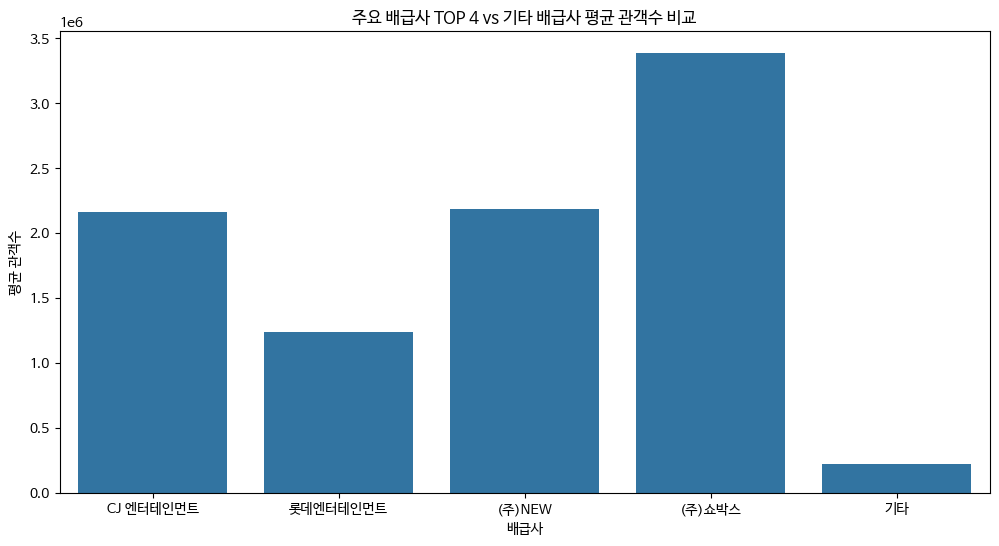

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(data=train_clean, x='배급사_분류', y='box_off_num', errorbar=None, order=list(top4_list) + ['기타'])

plt.title('주요 배급사 TOP 4 vs 기타 배급사 평균 관객수 비교')
plt.xlabel('배급사')
plt.ylabel('평균 관객수')
plt.show()

대형 배급사들이 기타 배급사 그룹을 몇 배 이상 앞지르는 것을 알 수 있다.<br> 결론적으로 '대형 자본 -> 많은 스텝 투입 -> 높은 관객 수' 라는 흥행 공식이 데이터로 입증된 셈이다. 영화 산업에서 배급사의 규모는 단순히 이름값이 아니라 제작에 투입되는 자본의 양을 결정하고 이것이 결국 최종 흥행 성적을 가르는 결정적인 차이를 만든다.

# **장르별 주연배우 수 분석**

- 가설 : 멜로/로맨스 장르의 주연배우 수는 2~3명, 다수의 세력이 충돌하는 액션/느와르 장르는 5명 이상의 주연배우가 등장하는 비중이 높을 것이다.

<데이터 전처리>

주연배우가 0명인 영화, 주연배우 개념이 모호한 다큐멘터리는 제외하고 분석하였다. (9개 제외)

In [17]:
zero_actors_df =train[train.num_actor == 0]
zero_actors_df[['title', 'genre', 'num_actor', 'director']]

,title,genre,num_actor,director
107,미국의 바람과 불,다큐멘터리,0,김경만
167,모래가 흐르는 강,다큐멘터리,0,지율스님
168,망대,다큐멘터리,0,문승욱
355,오디세오,뮤지컬,0,정성복
391,명령불복종 교사,다큐멘터리,0,서동일
418,오월愛,다큐멘터리,0,김태일
425,보라,다큐멘터리,0,이강현
437,나쁜 나라,다큐멘터리,0,김진열
456,"60년전, 사선에서",다큐멘터리,0,박성미


In [18]:
train = train[train.num_actor > 0] ## 주연배우 수가 0명인 데이터 제외
train = train[train.genre != '다큐멘터리'] ## 다큐멘터리 장르 제외

train[['genre', 'num_actor']]

,genre,num_actor
0,액션,2
1,느와르,3
2,액션,4
3,코미디,6
4,코미디,2
...,...,...
595,드라마,7
596,드라마,6
597,공포,4
598,느와르,4


<시각화>

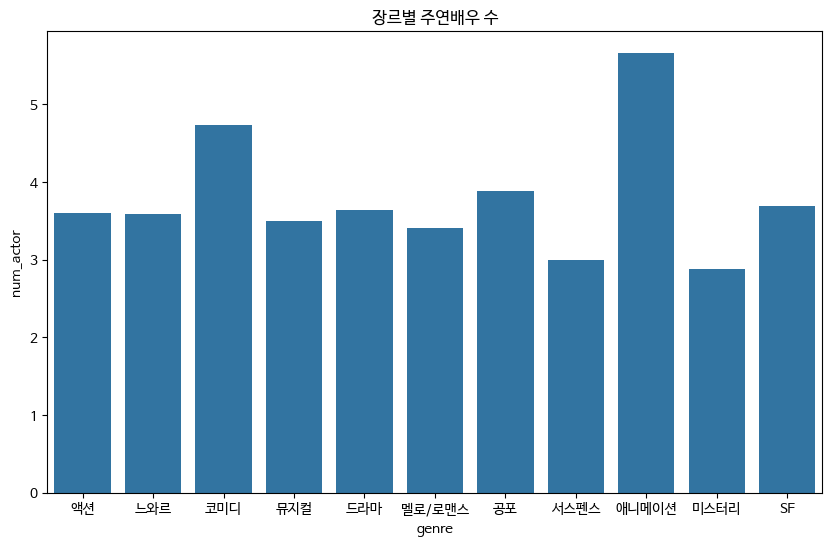

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x='genre', y='num_actor', data=train, errorbar=None)
plt.title('장르별 주연배우 수') ## 주연배우 수가 0명, 다큐멘터리 데이터 제외
plt.show()

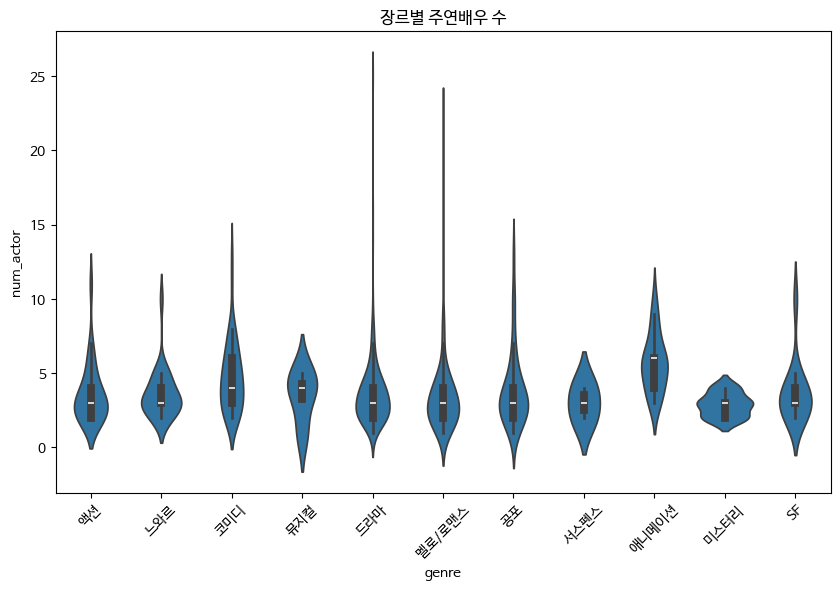

In [20]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='genre', y='num_actor', data=train)
plt.title('장르별 주연배우 수')
plt.xticks(rotation=45)
plt.show()

In [21]:
## 장르별 주연배우 수의 평균 (내림차순)
genre_mean_sorted = train.groupby('genre')['num_actor'].mean().sort_values(ascending=False).round(1)
genre_mean_sorted

,num_actor
genre,
애니메이션,5.7
코미디,4.7
공포,3.9
SF,3.7
드라마,3.6
액션,3.6
느와르,3.6
뮤지컬,3.5
멜로/로맨스,3.4


(1) 가설 검증 결과
- 멜로/로맨스: 평균 주연배우 수가 약 3.4명
-> 가설과 유사한 수치를 보였다.

- 액션/느와르: 액션과 느와르 장르 모두 평균 약 3.6명
-> 예상보다 적게 나타났다.

(2) 주요 특징

- 주연배우가 가장 많은 장르: 애니메이션(약 5.7명)

- 주연배우가 2번째로 많은 장르: 코미디(약 4.7명)

- 주연배우가 가장 적은 장르: 미스터리 장르(약 2.9명)

(3) 전반적 분포

애니메이션과 코미디를 제외한 대부분의 영화 장르에서 평균 3~4명의 주연배우를 출연시키는 것으로 확인된다.

초기 가설에서는 스케일이 큰 액션/느와르 장르의 주연배우가 5명 이상으로 가장 많을 것으로 예상했다.

하지만 실제 데이터 분석 결과, 액션/느와르는 평균 3.6명에 그쳤고, 오히려 애니메이션(5.7명)과 코미디(4.7명)가 가장 높게 나타났다.

액션물은 소수의 핵심 주인공(히어로 vs 빌런)에게 서사가 집중되는 반면, 코미디 영화 특성상 한두 명의 주인공보다는 여러 캐릭터가 다 함께 중심이 되어 에피소드를 이끌어가는 다수 주연 체제(가족 코미디 등)가 많기 때문으로 해석된다.

##+) 추가분석) 장르마다 허용하는 캐스팅의 유연성

앞에서 분석한 '평균 주연배우 수'만으로는 특정 장르에 주연이 극단적으로 많거나 적은 예외적 사례들을 파악하기 어렵다.

따라서 각 장르가 서사의 규모에 따라 주연배우의 수를 얼마나 폭넓게 허용하는지 확인하기 위해 바이올린 플롯을 사용해 데이터의 전반적인 분포를 추가 분석했다.

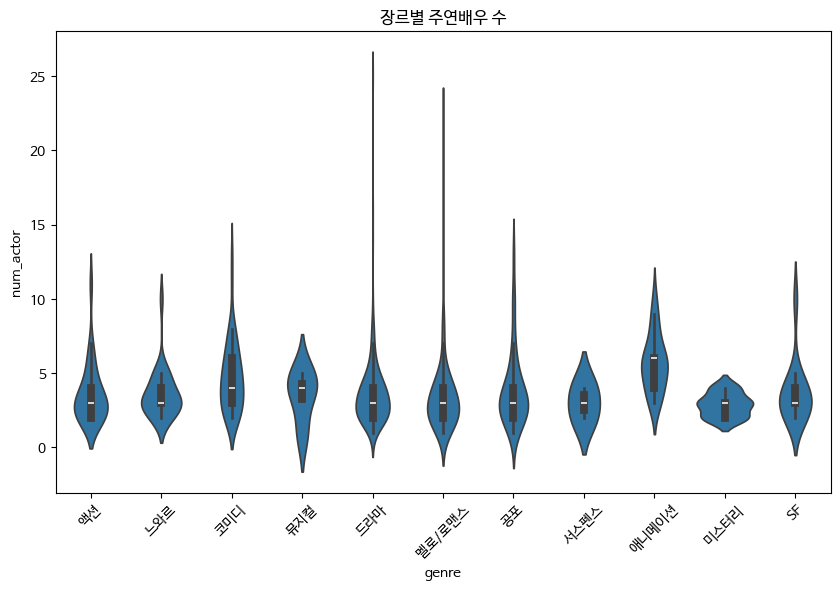

In [22]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='genre', y='num_actor', data=train)
plt.title('장르별 주연배우 수')
plt.xticks(rotation=45)
plt.show()

드라마 장르의 분포 꼬리가 다른 장르에 비해 극단적으로 상단을 향해 길게 뻗어 있는 것을 확인할 수 있다.

데이터 상 주연배우가 4명 이상인 작품을 앙상블(Ensemble) 영화라고 지칭하고 각 장르 내 앙상블 영화가 차지하는 비중(%)을 분석하였다.

In [23]:
## 장르별 앙상블 영화 비율(%)
ensemble_ratio = (train['num_actor'] >= 4).groupby(train['genre']).mean() * 100
result = ensemble_ratio.sort_values(ascending=False).map("{:.1f}%".format)
result

,num_actor
genre,
애니메이션,85.7%
뮤지컬,75.0%
코미디,66.0%
서스펜스,50.0%
드라마,42.1%
SF,38.5%
공포,38.1%
느와르,37.0%
멜로/로맨스,35.9%


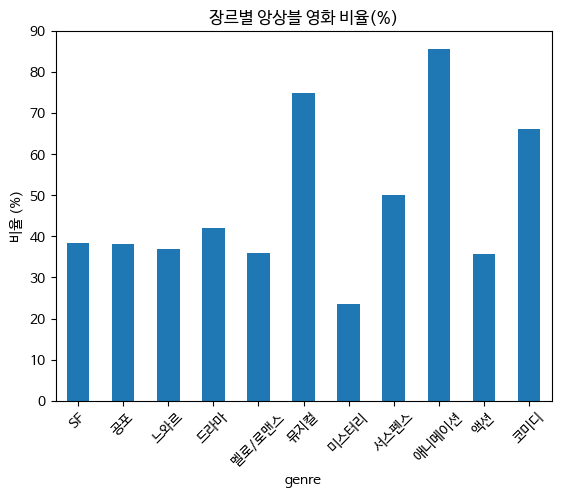

In [24]:
ensemble_ratio.plot(kind='bar')

plt.title('장르별 앙상블 영화 비율(%)')
plt.ylabel('비율 (%)')
plt.xticks(rotation=45)
plt.show()

비율을 확인해보니 드라마가 아닌 애니메이션이 85.7%로 비율이 가장 높았다.

In [25]:
genre_counts = train['genre'].value_counts()
genre_counts

,count
genre,
드라마,221
멜로/로맨스,78
코미디,53
공포,42
액션,28
느와르,27
애니메이션,21
미스터리,17
SF,13


장르별 전체 제작 편수를 확인한 결과 '드라마'는 221편으로 가장 많은 비중을 차지한 반면 '애니메이션'은 21편에 불과했다. 두 장르의 데이터가 약 10배 차이나는 것을 알 수 있다.

바이올린 플롯에서 확인된 드라마 장르의 긴 꼬리 형태는 드라마가 타 장르에 비해 캐스팅의 유연성이 독보적으로 높아서라기보다 표본 크기(221편)가 방대해 예외 사례가 포함되며 분포가 확장된 결과로 해석된다.

애니메이션은 제작 편수는 적지만 전체 작품 중 앙상블 캐스팅이 차지하는 비중이 매우 높아 해당 방식에 가장 최적화된 장르임이 데이터를 통해 입증되었다.

# **개봉시기와 영화장르의 상관관계**

- 가설1: 여름에 겨울보다 공포영화가 더 흥행할 것이다.
- 가설2: 드라마 장르는 봄과 가을에 더 흥행할 것이다. (로맨스, 멜로는 표본이 드라마보다 상대적으로 적어 드라마 장르로 선택)

<데이터 전처리>
1. release_time을 시계열 데이터로 변환하여 release_time_dt 변수에 저장

2. 개봉시기를 알아보기 위하여 release_month, season 변수를 새롭게 생성

In [26]:
train['release_time'].dtype

dtype('O')

In [27]:
#월(month), 계절(Season) 파생 변수 생성
train['release_time_dt'] = pd.to_datetime(train['release_time'])
train['release_month'] = train['release_time_dt'].dt.month

def get_season(month):
  if month in [3,4,5]:
    return '봄'
  elif month in [6,7,8]:
    return '여름'
  elif month in [9,10,11]:
    return '가을'
  else:
    return '겨울'
train['season'] = train['release_month'].apply(get_season)
print(train[['release_time_dt','release_month','season']].head())

  release_time_dt  release_month season
0      2012-11-22             11     가을
1      2015-11-19             11     가을
2      2013-06-05              6     여름
3      2012-07-12              7     여름
4      2010-11-04             11     가을


<시각화>

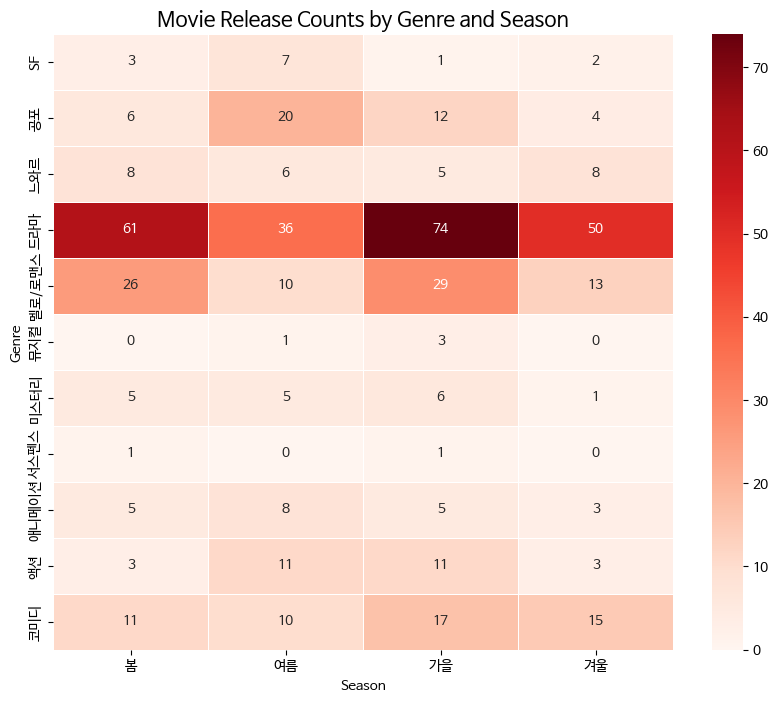

In [31]:
plt.figure(figsize=(10, 8))

genre_season_count = pd.crosstab(train['genre'], train['season'])
genre_season_count = genre_season_count.reindex(columns=season_order)
sns.heatmap(genre_season_count,
            annot=True,      # 개봉 편수 숫자 표시
            fmt="d",         # 정수형(Integer) 포맷
            cmap="Reds",     # 빈도가 높을수록 붉은색
            linewidths=.5)

plt.title('Movie Release Counts by Genre and Season', fontsize=15)
plt.xlabel('Season')
plt.ylabel('Genre')
plt.show()

각 계절별로 영화 개봉 편수를 장르로 나누어 파악해보았다.
- 드라마 장르는 사계절 많이 개봉한다. 특히나 가을에 개봉이 몰리는 경향이 있다.
- 공포영화는 여름에, 멜로/로맨스 장르는 봄,가을에 집중적으로 개봉하는 것을 알 수 있다.

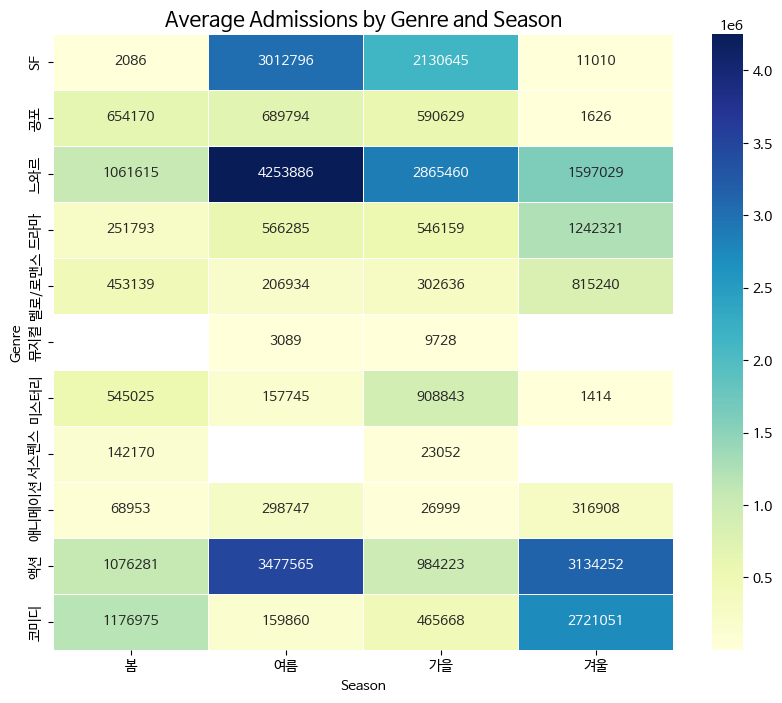

In [38]:
pivot_df = train.pivot_table(index='genre',
                         columns='season',
                         values='box_off_num',
                         aggfunc='mean')

season_order = ['봄', '여름', '가을', '겨울']
pivot_df = pivot_df.reindex(columns=season_order)

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df,
            annot=True,
            fmt=".0f",       # 소수점 제거
            cmap='YlGnBu',
            linewidths=.5)

plt.title('Average Admissions by Genre and Season', fontsize=15)
plt.xlabel('Season')
plt.ylabel('Genre')
plt.show()

각 계절 별로 평균 관객 수가 많은 장르를 알아보았다.<br>
봄에는 코미디, 액션, 느와르, 여름에는 느와르, 액션, SF 순으로 평균 관객 수가 많았으며, 가을에는 느와르, SF, 액션 순, 겨울에는 액션, 코미디, 느와르 순으로 평균 관객 수가 많음을 알 수 있다.

(1) 공포영화는 추운 겨울보다 더운 여름에 더 흥행할 것이다.

In [32]:
from scipy import stats

# 1. 공포 영화 데이터만 추출
horror_df = train[train['genre'] == '공포'].copy()

# 2. 그룹 나누기: 여름(6, 7, 8월) vs 겨울(12, 1, 2월)
# 각각의 월에 해당하는 데이터만 필터링합니다.
summer_horror = horror_df[horror_df['release_month'].isin([6, 7, 8])]['box_off_num']
winter_horror = horror_df[horror_df['release_month'].isin([12, 1, 2])]['box_off_num']

# 3. T-test 수행 (독립표본 T-검정)
# nan_policy='omit'을 추가하여 혹시 모를 결측치를 제외하고 계산합니다.
t_stat, p_val = stats.ttest_ind(summer_horror, winter_horror, equal_var=False, nan_policy='omit')

# 4. 결과 출력
print(f"여름 개봉 공포영화 평균 관객수: {summer_horror.mean():.2f}명 (샘플 수: {len(summer_horror)}개)")
print(f"겨울 개봉 공포영화 평균 관객수: {winter_horror.mean():.2f}명 (샘플 수: {len(winter_horror)}개)")
print("-" * 30)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# 5. 결과 해석
if p_val < 0.05:
    print("\n[결과] 통계적으로 유의미한 차이가 있습니다.")
    if summer_horror.mean() > winter_horror.mean():
        print(" '여름 공포 영화'가 겨울보다 더 흥행한다.")
    else:
        print("의외로 '겨울 공포 영화'가 여름만큼 흥행한다")
else:
    print("\n[결과] 통계적으로 유의미한 차이가 없습니다.")
    print("공포 영화에게 여름과 겨울은 흥행 면에서 큰 차이가 없는 없다.")

여름 개봉 공포영화 평균 관객수: 689794.50명 (샘플 수: 20개)
겨울 개봉 공포영화 평균 관객수: 1625.50명 (샘플 수: 4개)
------------------------------
T-statistic: 2.3556
P-value: 0.0294

[결과] 통계적으로 유의미한 차이가 있습니다.
 '여름 공포 영화'가 겨울보다 더 흥행한다.


계절이 현실적으로는 이산적으로 나눌 수 없기 때문에 여름과 겨울이라는 반대편에 있는 계절로만 분석을 진행하였다. T-test를 진행한 결과 여름에 개봉하는 공포영화가 겨울에 개봉하는 공포영화보다 유의미하게 더 흥행한다.

(2) 드라마 영화는 봄,가을에 개봉하면 여름,겨울에 개봉하는 것보다 흥행할 것이다.

In [36]:
from scipy import stats

# 1. 드라마 영화 데이터만 추출
drama_df = train[train['genre'] == '드라마'].copy()

# 2. 그룹 나누기: 가설의 주인공인 [봄, 가을] vs 대조군인 [여름, 겨울]
# 봄(3,4,5월) + 가을(9,10,11월)
off_season_months = [3, 4, 5, 9, 10, 11]
drama_df['is_target_season'] = drama_df['release_month'].isin(off_season_months)

spring_fall_group = drama_df[drama_df['is_target_season'] == True]['box_off_num']
summer_winter_group = drama_df[drama_df['is_target_season'] == False]['box_off_num']

# 3. T-test 수행 (독립표본 T-검정)
t_stat, p_val = stats.ttest_ind(spring_fall_group, summer_winter_group, equal_var=False, nan_policy='omit')

# 4. 결과 출력
print(f"봄·가을 개봉 드라마 평균 관객수: {spring_fall_group.mean():.2f}명")
print(f"여름·겨울 개봉 드라마 평균 관객수: {summer_winter_group.mean():.2f}명")
print("-" * 30)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# 5. 가설 검증 결과
if p_val < 0.05:
    if spring_fall_group.mean() > summer_winter_group.mean():
        print("\n[가설 채택] 봄·가을에 개봉한 드라마 영화가 여름·겨울보다 통계적으로 유의미하게 흥행한다.")
    else:
        print("\n[가설 기각] 봄·가을에 개봉한 드라마 영화가 여름·겨울보다 통계적으로 유의미하게 성적이 좋다고 할 수 없다.")
else:
    print("\n[가설 기각] 봄·가을과 여름·겨울 간의 흥행 차이가 통계적으로 유의미하지 않습니다.")

봄·가을 개봉 드라마 평균 관객수: 413149.09명
여름·겨울 개봉 드라마 평균 관객수: 959329.27명
------------------------------
T-statistic: -1.9935
P-value: 0.0483

[가설 기각] 봄·가을에 개봉한 드라마 영화가 여름·겨울보다 통계적으로 유의미하게 성적이 좋다고 할 수 없다.


드라마 영화의 경우 봄 가을에 개봉한 영화의 편수가 더 많긴 했으나, 유의수준 0.05에서 통계적으로 유의미하게 봄,가을에 성적이 더 좋다고 할 수는 없다.

(3) 멜로/로맨스 드라마는 봄,가을에 개봉하면 여름, 겨울에 개봉하는 것보다 더 흥행할 것이다.

In [40]:
from scipy import stats

# 1. 드라마 영화 데이터만 추출
MR_df = train[train['genre'] == '멜로/로맨스'].copy()

# 2. 그룹 나누기
# 봄(3,4,5월) + 가을(9,10,11월)
off_season_months = [3, 4, 5, 9, 10, 11]
MR_df['is_target_season'] = MR_df['release_month'].isin(off_season_months)

spring_fall_group2 = MR_df[MR_df['is_target_season'] == True]['box_off_num']
summer_winter_group2 = MR_df[MR_df['is_target_season'] == False]['box_off_num']

# 3. T-test 수행 (독립표본 T-검정)
t_stat, p_val = stats.ttest_ind(spring_fall_group2, summer_winter_group2, equal_var=False, nan_policy='omit')

# 4. 결과 출력
print(f"봄·가을 개봉 드라마 평균 관객수: {spring_fall_group2.mean():.2f}명")
print(f"여름·겨울 개봉 드라마 평균 관객수: {summer_winter_group2.mean():.2f}명")
print("-" * 30)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# 5. 가설 검증 결과
if p_val < 0.05:
    if spring_fall_group2.mean() > summer_winter_group2.mean():
        print("\n[가설 채택] 봄·가을에 개봉한 멜로/로맨스 영화가 여름·겨울보다 통계적으로 유의미하게 흥행한다.")
    else:
        print("\n[가설 기각] 봄·가을에 개봉한 멜로/로맨스 영화가 여름·겨울보다 통계적으로 유의미하게 성적이 좋다고 할 수 없다.")
else:
    print("\n[가설 기각] 봄·가을과 여름·겨울 간의 흥행 차이가 통계적으로 유의미하지 않습니다.")

봄·가을 개봉 드라마 평균 관객수: 373782.73명
여름·겨울 개봉 드라마 평균 관객수: 550759.00명
------------------------------
T-statistic: -0.7821
P-value: 0.4384

[가설 기각] 봄·가을과 여름·겨울 간의 흥행 차이가 통계적으로 유의미하지 않습니다.


배급사에서는 봄과 가을에 멜로/로맨스 장르를 많이 개봉하나, 흥행에 유리한 조건으로 작용하지는 않는 것으로 나타났다.

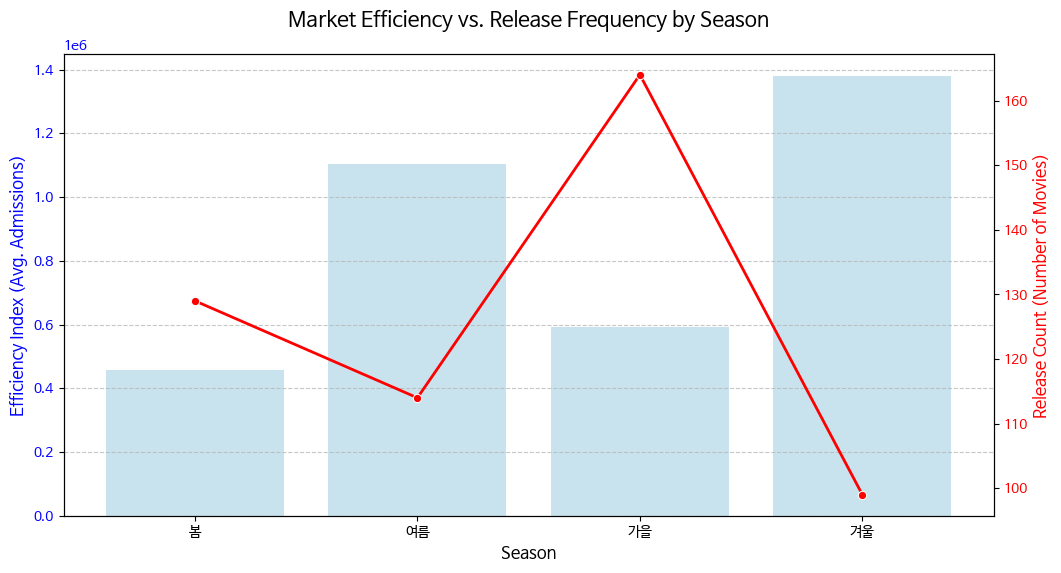

In [37]:
# 1. 데이터 준비 (season_stats 표 생성 및 계절 순서 정렬)
# .reindex(['봄', '여름', '가을', '겨울'])를 추가하여 가나다 순서를 바꿉니다.
season_stats = train.groupby('season')['box_off_num'].agg(['sum', 'count']).reindex(['봄', '여름', '가을', '겨울'])
season_stats['efficiency'] = season_stats['sum'] / season_stats['count']

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. 막대 그래프: 효율성 지수 (왼쪽 y축)
# 순서가 정렬된 season_stats.index를 사용하므로 자동으로 봄->겨울 순으로 그려집니다.
sns.barplot(x=season_stats.index, y=season_stats['efficiency'], alpha=0.5, color='skyblue', ax=ax1)
ax1.set_ylabel('Efficiency Index (Avg. Admissions)', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 3. 꺾은선 그래프: 개봉 편수 (오른쪽 y축)
ax2 = ax1.twinx()  # x축을 공유하는 새로운 y축 생성
sns.lineplot(x=season_stats.index, y=season_stats['count'], color='red', marker='o', linewidth=2, ax=ax2)
ax2.set_ylabel('Release Count (Number of Movies)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# 4. 그래프 제목 및 레이아웃 정리
plt.title('Market Efficiency vs. Release Frequency by Season', fontsize=15, pad=20)
ax1.set_xlabel('Season', fontsize=12)

# 그리드 추가 (주 축 기준)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

여름과 겨울이 효율성지수가 높다. 즉, 영화시장 자체가 커지는 시기는 여름과 겨울이다.<br>
봄과 가을에는 상대적으로 저조한 지수를 보인다.
<br>
<br>
* 겨울: 개봉 편수(빨강)는 가장 적은데, 효율성을 가장 높다. 즉, 경쟁자가 거의 없는 상태에서 관객을 독실할 수 있는 블루오션이다.

* 가을: 개봉편수는 가장 많지만, 효율성이 많이 떨어진다. 즉, 영화는 쏟아져 나오지만 과잉 경쟁인 레드오션이다.
<br>
<br>

우리의 추론은 '여름엔 공포영화'라는 생각이 있으니 공포영화도 잘 되겠지?로 이어지지만, 다른 작품들과 경쟁이 치열하다.

**즉, '시기적 이점'이 '치열한 경쟁'에 의해 상쇄되는 것이다.**